# Model Fine-tuning with the Hugging Face `transformers` Library

Previously, we learned [how to use Apple's MLX framework to fine-tune a language model](/howtos/fine-tuning/mlx/). This is an Apple specific framework and is not available to everyone. Here we will learn how to fine-tune a language model using the Hugging Face [`transformers`](https://huggingface.co/docs/transformers/en/index) library. This library is widely used and supports a variety of models on different platforms and hardware.

It is also the basis for many other tools, such as [`Axolotl`](https://github.com/axolotl-ai-cloud/axolotl) and [`unsloth`](https://unsloth.ai) which ease and automate much of the fine-tuning pipeline. Even if you rely on these tools for your work, it is still important to understand the underlying `transformers` library and how to use it directly, even if only to get an intuition for how these tools work.

As we did before when we fine-tuned a model with MLX, we will use the LoRA approach as opposed to fine-tuning the entire model.

In [1]:
import random
import numpy as np
import torch

SEED = 42

random.seed(SEED)

In [2]:
from transformers import set_seed

set_seed(SEED)  # Covers Transformers, Tokenizers, and Datasets

## Producing a training dataset

In this example, we will be fine-tuning a tiny [`Qwen2.5-0.5B-Instruct`](https://huggingface.co/Qwen/Qwen2.5-0.5B-Instruct) model to perform very basic arithmetic operations. We will generate a dataset of arithmetic problems and their solutions to train the model. Qwen2.5 is an open-source model from Alibaba, which offers a collection of language models trained on a variety of tasks.

Let us start with a function which generates the necessary dataset in the appropriate chat format for the `transformers` library.

In [3]:
import random
from datasets import Dataset

def generate_arithmetic_dataset(n_samples: int) -> Dataset:
    """
    Generates arithmetic problems using numbers 0-100 in the specified message format
    """
    operations = ['+', '-', '*']
    samples = []

    for _ in range(n_samples):
        # Generate arithmetic problem with 0-100 numbers
        op = random.choice(operations)
        x = random.randint(0, 200)
        y = random.randint(0, 200)

        # Calculate result with clean formatting
        if op == '+':
            result = x + y
        elif op == '-':
            y = random.randint(0, x)
            result = x - y
        elif op == '*':
            result = x * y

        # Create problem string without negative formatting
        problem = f"{x}{op}{y}"
        
        # Format final equation
        #full_equation = f"x is {result}"
        full_equation = f"x is {result}"
        
        variations = [  
            # Prepositional Variations  
            f"Assuming x={problem}, solve for x.",  
            f"Provided x={problem}, solve for x.",  
            f"With x={problem} given, solve for x.",  
            f"Under the condition x={problem}, solve for x.",  
            f"Using x={problem}, solve for x.",  

            # Conditional Clause Variations  
            f"If x={problem} is provided, solve for x.",  
            f"When x={problem} is given, solve for x.",  
            f"In the case where x={problem}, solve for x.",  
            f"For the equation x={problem}, solve for x.",  
            f"Given that x={problem}, solve for x.",  

            # Participial Phrase Variations  
            f"Starting from x={problem}, solve for x.",  
            f"Taking x={problem} into account, solve for x.",  
            f"Having x={problem}, solve for x.",  
            f"Basing your work on x={problem}, solve for x.",  
            f"Considering x={problem}, solve for x.",  

            # Imperative Variations  
            f"Solve for x, given x={problem}.",  
            f"Use x={problem} to solve for x.",  
            f"Work with x={problem} and solve for x.",  
            f"Begin with x={problem}, then solve for x.",  
            f"Take x={problem} and solve for x.",  

            # Expanded/Explicit Variations  
            f"Given the value x={problem}, determine the solution for x.",  
            f"Using the premise that x={problem}, find the value of x.",  
            f"Under the assumption that x={problem}, compute x.",  
            f"If we define x as {problem}, solve for x.",  
            f"Based on the equation x={problem}, solve for x.",  
    ]

        # Create conversation structure
        prompt = random.choice(variations)
        
        samples.append({
            "messages": [
                {
                    "content": prompt,
                    "role": "user"
                },
                {
                    "content": full_equation,
                    "role": "assistant"
                }
            ],
        })

    return Dataset.from_list(samples)

In [4]:
dataset = generate_arithmetic_dataset(20000)

dataset

Dataset({
    features: ['messages'],
    num_rows: 20000
})

With the dataset generated, let us look at a few examples to understand what we will be training the model on.

In [5]:
# Show first few dataset entries
for i in range(10):
    print(dataset[i])

{'messages': [{'content': 'If we define x as 28*6, solve for x.', 'role': 'user'}, {'content': 'x is 168', 'role': 'assistant'}]}
{'messages': [{'content': 'If we define x as 62-8, solve for x.', 'role': 'user'}, {'content': 'x is 54', 'role': 'assistant'}]}
{'messages': [{'content': 'Work with x=173+189 and solve for x.', 'role': 'user'}, {'content': 'x is 362', 'role': 'assistant'}]}
{'messages': [{'content': 'Provided x=151+108, solve for x.', 'role': 'user'}, {'content': 'x is 259', 'role': 'assistant'}]}
{'messages': [{'content': 'In the case where x=23+55, solve for x.', 'role': 'user'}, {'content': 'x is 78', 'role': 'assistant'}]}
{'messages': [{'content': 'Work with x=154*6 and solve for x.', 'role': 'user'}, {'content': 'x is 924', 'role': 'assistant'}]}
{'messages': [{'content': 'Under the assumption that x=183+166, compute x.', 'role': 'user'}, {'content': 'x is 349', 'role': 'assistant'}]}
{'messages': [{'content': 'Considering x=107*56, solve for x.', 'role': 'user'}, {'c

We are providing the model with basic arithmetic problems. Think of this as a simple calculator for 7 year olds, where we want the model to recognize a pattern of problems, and to be able to return back a consistent output which doesn't vary in form for a variety of inputs. The format you see above is called the `chat` format, which is a simple JSON format that the `transformers` library uses for training. It is also used by OpenAI in their GPT API.

```{admonition} Exercise suggestion
:class: note, dropdown

As an exercise, maybe you want to try training a similar model to interpret a similar problem expressed in JSON format, and to return the answer in structured JSON.
```

## Loading the model

With a dataset ready, we can now load the model we want to fine-tune. We will use the `Qwen2.5-0.5B-Instruct` model from the Hugging Face model hub. This is a tiny model with half a billion parameters, and is a good starting point for fine-tuning experiments as it requires less computational resources.

In [6]:
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "Qwen/Qwen2.5-0.5B-Instruct"

model = AutoModelForCausalLM.from_pretrained(
    model_name
)
tokenizer = AutoTokenizer.from_pretrained(
    model_name
)

model.config.use_cache = False  # important with gradient checkpointing

/Volumes/Home/pedroleitao/miniconda3/envs/ml-env-latest/lib/python3.11/site-packages/torchvision/io/image.py:14: UserWarning: Failed to load image Python extension: 'dlopen(/Volumes/Home/pedroleitao/miniconda3/envs/ml-env-latest/lib/python3.11/site-packages/torchvision/image.so, 0x0006): Library not loaded: @rpath/libjpeg.9.dylib
  Referenced from: <BFAC0362-079C-3D60-A731-79532A75BA60> /Volumes/Home/pedroleitao/miniconda3/envs/ml-env-latest/lib/python3.11/site-packages/torchvision/image.so
  Reason: tried: '/Volumes/Home/pedroleitao/miniconda3/envs/ml-env-latest/lib/python3.11/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/Volumes/Home/pedroleitao/miniconda3/envs/ml-env-latest/lib/python3.11/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/Volumes/Home/pedroleitao/miniconda3/envs/ml-env-latest/lib/python3.11/lib-dynload/../../libjpeg.9.dylib' (no such file), '/Volumes/Home/pedroleitao/miniconda3/envs/ml-env-latest/bin/../lib/libjpeg.9.dylib'

For reference, the input to the model will be tokenized using the model's tokenizer, and the output will be a sequence of tokens, in a format called `ChatML`, which includes special tokens which are meaningful the pre-trained model.

In [7]:
tokenizer.apply_chat_template(dataset[0]["messages"], tokenize=False)

'<|im_start|>system\nYou are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>\n<|im_start|>user\nIf we define x as 28*6, solve for x.<|im_end|>\n<|im_start|>assistant\nx is 168<|im_end|>\n'

Notice the `<|im_start">` and `<|im_end|>` tokens. These are special tokens that the model uses to understand the start and end of the input sequence for each role (the prompter, and the assistant which represents the expected output from the model). The model will be trained to generate the output sequence between these tokens.

Before we start training, let's split the dataset into training and validation sets.

In [8]:
dataset = dataset.train_test_split(test_size=0.1)

dataset

DatasetDict({
    train: Dataset({
        features: ['messages'],
        num_rows: 18000
    })
    test: Dataset({
        features: ['messages'],
        num_rows: 2000
    })
})

Let's also look at the architecture of the model we are fine-tuning. It is important to have a sense of the model's layers as this will directly impact how LoRA will be applied.

In [9]:
from pprint import pprint

pprint(model)

Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 896)
    (layers): ModuleList(
      (0-23): 24 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear(in_features=896, out_features=896, bias=True)
          (k_proj): Linear(in_features=896, out_features=128, bias=True)
          (v_proj): Linear(in_features=896, out_features=128, bias=True)
          (o_proj): Linear(in_features=896, out_features=896, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=896, out_features=4864, bias=False)
          (up_proj): Linear(in_features=896, out_features=4864, bias=False)
          (down_proj): Linear(in_features=4864, out_features=896, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm((896,), eps=1e-06)
    (rotary_emb): Qwen2RotaryEmbe

Imagine the entire model as `Qwen2ForCausalLM`. At its core, we have `Qwen2Model`, which contains several parts. First, there's an embedding layer (`embed_tokens`) that transforms tokens from a large vocabulary into 896-dimensional vectors. These vectors are then processed by 24 identical layers, which we can denote as L₀ to L₂₃ (each being a `Qwen2DecoderLayer`).

Inside each layer Lᵢ, the process starts with self-attention (`self_attn`), where the input is projected into three spaces: queries (via `q_proj`), keys (via `k_proj`), and values (via `v_proj`). These projections are linear transformations that help the model focus on relevant parts of the input. After the attention calculations, the results are recombined through `o_proj`, another linear transformation that brings the data back to the original 896 dimensions.

Following attention, each layer includes a feed-forward network (`mlp`). This part consists of a couple of linear layers: `gate_proj` and `up_proj` expand the data to a larger dimension (4864), then `down_proj` compresses it back to 896. An activation function, `SiLU`, introduces non-linearity, allowing the model to capture more complex patterns.

Also within each layer Lᵢ, there are two normalization modules: `input_layernorm` is applied before the self-attention to stabilize the inputs, and `post_attention_layernorm` is applied after self-attention to help keep the network stable as the data moves through the layer.

After processing through all 24 layers, the model applies a final normalization `norm` to the output. Alongside these, there's a rotary embedding module, `rotary_emb`, which helps encode positional information into the vectors.

Finally, the processed data is fed into `lm_head`, which is a linear layer that projects the final 896-dimensional representations back to the vocabulary size (151936). This final step allows the model to predict the next token based on the processed context.

LoRA essentially adds small, trainable “patches” to the existing linear layers without modifying the core weights. Imagine each weight matrix, like those in `q_proj` or in the feed-forward network (`gate_proj`, `up_proj`, `down_proj`), is now accompanied by an extra low-rank update. Instead of changing the full 896×896 matrix directly, LoRA introduces two smaller matrices whose product—when added to the original weight—captures the necessary adjustment during fine-tuning. This means that during training, only these additional matrices are updated, leaving the main model untouched. In our architecture, LoRA can be applied to components like the attention projections and MLP layers, efficiently steering the model to adapt to new tasks with much fewer trainable parameters.

## Configuring LoRA

Now that we have a sense of the model's architecture, we can configure LoRA. The setup uses small matrices (`rank 16`) are added to specific parts of the model. The number 32 (`alpha`) controls how much these new matrices affect the original weights – like a volume knob for the adjustments. A small 5% dropout (`lora_dropout`) is applied to these added components to prevent overfitting.

It targets all linear layers (`target_modules`) in the model for adaptation (like attention and feed-forward layers) while explicitly keeping the word embedding layer and the final output layer (`lm_head`) fully trainable. The `bias` terms in the original model remain frozen. This configuration is specifically designed for causal language modeling tasks like text generation, where the model predicts the next word in a sequence. The approach balances efficiency (only modifying parts of the model) with flexibility (keeping key components like embeddings trainable).

```{admonition} About the LoRA `rank`
:class: note, dropdown

When we talk about "rank 16" in LoRA, we’re simplifying how a large language model gets adjusted during fine-tuning. Imagine you have a giant spreadsheet of numbers (the model’s weights) that controls how the model behaves. Updating every single number in that spreadsheet would take a lot of time and energy. Instead, LoRA uses a clever shortcut: it breaks down those updates into two smaller, simpler spreadsheets.

The "rank" (in this case, 16) determines how "detailed" these smaller spreadsheets are. A rank of 16 means we’re capturing the most important 16 patterns or directions in the data needed to tweak the model. Think of it like summarizing a long, complicated book with just 16 key bullet points—enough to get the main ideas without memorizing every word.

By using rank 16, LoRA trains only a tiny fraction of the original parameters, making the process faster and more efficient. The trade-off is that we’re approximating changes rather than updating everything perfectly, but in practice, this works surprisingly well for adapting models to new tasks. The value 16 itself is a balance—small enough to save resources, but large enough to retain useful flexibility for learning.
```

In [10]:
from peft import LoraConfig

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    target_modules="all-linear",
    modules_to_save=["lm_head", "embed_token"],
    task_type="CAUSAL_LM"
)

## Configuring the trainer

With the model and LoRA configured, we can now set up the trainer. We will use the [`TRL`](https://huggingface.co/docs/trl/en/index) library, which provides a number of fine-tuning strategies, including supervised fine-tuning, reinforcement learning, direct preference optimization, and more. In this case, we will use the supervised fine-tuning strategy.

First, we need to configure the training arguments. We will set the number of epochs to 5, the learning rate to 2e-5, and the batch size to 4. Depending on what precisely you are fine-tuning the model for, you will need to adjust these values for best results.

In [11]:
from trl import SFTConfig

# For this to work on Apple Silicon, PYTORCH_ENABLE_MPS_FALLBACK=1 must be set as an environment variable

training_args = SFTConfig(
    output_dir=f"{model_name}-finetuned",
    logging_dir="logs",
    num_train_epochs=5,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    learning_rate=2e-5,
    warmup_ratio=0.05,
    logging_steps=50,
    eval_strategy="steps",
    eval_steps=100,
    save_strategy="steps",
    save_steps=100,
    max_seq_length=128,
    gradient_checkpointing=True,
    report_to="none",
    fp16=False,
    load_best_model_at_end=True,   # Necessary for early stopping
    metric_for_best_model="eval_loss"
)

We are using an evaluation strategy (`eval_strategy`) of `steps`, which means that the model will be evaluated every 100 steps. Again, depending on your dataset and model, you will need to adjust this value. Other evaluation strategies include no evaluation, and `epoch`, which evaluates the model at the end of each epoch. The warmup ratio (`warmup_ratio`) is set to 0.05, which means that the learning rate will increase linearly for the first 5% of the training steps.

```{admonition} About the warmup ratio
:class: note, dropdown

At the beginning of training, the learning rate (how aggressively the model updates its weights) starts very low, often near zero. Over a small fraction of the total training steps (determined by the `warmup_ratio`), the learning rate slowly increases to its maximum value. For example, if your total training is 1000 steps and the warmup_ratio is 0.1, the first 100 steps will gradually "warm up" the learning rate. This helps prevent the model from making erratic, unstable updates early on, when its initial guesses are still random. After the warmup phase, the learning rate typically follows a schedule (like decreasing over time). A common ratio is 0.1 (10% of training steps), but it depends on the task — larger ratios give slower warmups, smaller ones start faster.
```

## Setting up the trainer

With the training arguments configured, we can now set up the trainer. We will use the `SFTTrainer` class from the `TRL` library. This class takes the model, training arguments, and the dataset as input. The trainer will implicitly use the model's tokenizer to tokenize the input data the way the model expects. We are also configuring an early stopping callback, which will stop training if the model's performance does not improve after 2 evaluations.

In [12]:
from trl import SFTTrainer
from transformers import EarlyStoppingCallback

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    dataset_text_field="messages",
    peft_config=lora_config,
    callbacks=[EarlyStoppingCallback(
        early_stopping_patience=2,
        early_stopping_threshold=0.005
    )]
)

/Volumes/Home/pedroleitao/miniconda3/envs/ml-env-latest/lib/python3.11/site-packages/huggingface_hub/utils/_deprecation.py:100: FutureWarning: Deprecated argument(s) used in '__init__': dataset_text_field. Will not be supported from version '0.13.0'.

Deprecated positional argument(s) used in SFTTrainer, please use the SFTConfig to set these arguments instead.
  warnings.warn(message, FutureWarning)
/Volumes/Home/pedroleitao/miniconda3/envs/ml-env-latest/lib/python3.11/site-packages/trl/trainer/sft_trainer.py:328: UserWarning: You passed a `dataset_text_field` argument to the SFTTrainer, the value you passed will override the one in the `SFTConfig`.
  warnings.warn(


Map:   0%|          | 0/18000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

We are now ready to kick off the training process. This will take some time, depending on the size of the model, the dataset, and the hardware you are using. It is a good idea to setup a checkpointing mechanism to save the model's state at regular intervals, so you can resume training if it is interrupted - we do so with `resume_from_checkpoint`.

In [13]:
from transformers.trainer_utils import get_last_checkpoint

last_checkpoint = get_last_checkpoint(training_args.output_dir)

trainer.train(
    resume_from_checkpoint=last_checkpoint
)

Step,Training Loss,Validation Loss
100,1.785100,0.984782
200,0.397700,0.352721
300,0.318000,0.318726
400,0.307100,0.311624
500,0.304800,0.306050
600,0.301500,0.304781
700,0.298700,0.304665


TrainOutput(global_step=700, training_loss=0.6854078742436001, metrics={'train_runtime': 1061.0737, 'train_samples_per_second': 84.82, 'train_steps_per_second': 5.301, 'total_flos': 1850739803504640.0, 'train_loss': 0.6854078742436001, 'epoch': 0.6222222222222222})

## Evaluating the training

Once the training is complete, we can evaluate the model on the validation set. We will use the `evaluate` method of the trainer to do this. The method will return a dictionary with the evaluation metrics. You will mostly be interested in the `eval_loss` value, which tells you how well the model is performing on the validation set, as well as the `perplexity` measure.

```{admonition} About perplexity
:class: note, dropdown

Perplexity, in the context of training a model like a language model, is a way to measure how "confused" the model is when trying to predict outcomes—like guessing the next word in a sentence. Think of it as a score that tells you how well the model understands the patterns in the data it’s trained on. If perplexity is low, the model is making confident, accurate predictions (like a student getting all answer right). If it’s high, the model is struggling (like a student guessing randomly).

Mathematically, it’s tied to how likely the model thinks the data it sees is. For example, if the model assigns high probabilities to correct answers (e.g., predicting the next word in a sentence), perplexity drops. If it spreads probability thinly across many wrong options, perplexity rises. A value of 20 means the model is, on average, as uncertain as if it had to choose between 20 equally likely options for every prediction.

During training, lowering perplexity on validation data is a key goal. It signals the model is learning meaningful patterns rather than memorizing noise.
```

In [14]:
import math

eval_results = trainer.evaluate()
print(eval_results)
final_loss = eval_results["eval_loss"]
final_ppl = math.exp(final_loss)
print("Perplexity:", final_ppl)

{'eval_loss': 0.3046654164791107, 'eval_runtime': 20.7463, 'eval_samples_per_second': 96.403, 'eval_steps_per_second': 12.05, 'epoch': 0.6222222222222222}
Perplexity: 1.356171174562185


Let's visualize the evaluation loss over the training steps to see how the model performed during training.

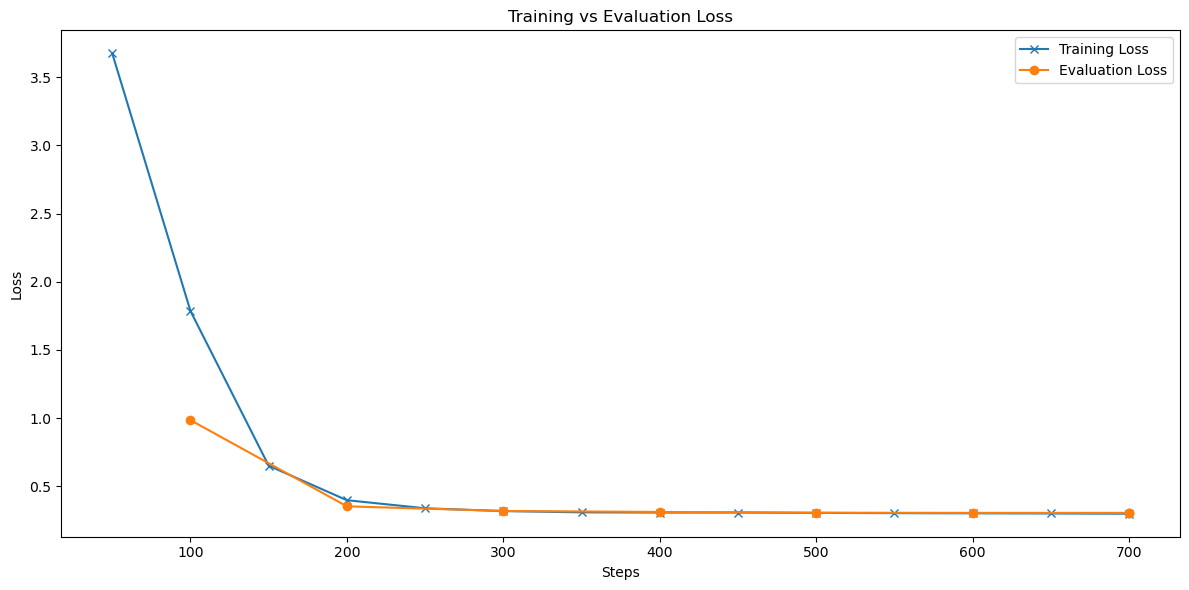

In [15]:
import matplotlib.pyplot as plt

# Collect training history
history = trainer.state.log_history

# Extract metrics
train_loss = [x['loss'] for x in history if 'loss' in x]
eval_loss = [x['eval_loss'] for x in history if 'eval_loss' in x]

# Create steps for x-axis
train_steps = [x['step'] for x in history if 'loss' in x]
eval_steps = [x['step'] for x in history if 'eval_loss' in x]

# Plot training and evaluation loss
plt.figure(figsize=(12, 6))

plt.plot(train_steps, train_loss, label='Training Loss', marker='x')
plt.plot(eval_steps, eval_loss, label='Evaluation Loss', marker='o')
plt.title('Training vs Evaluation Loss')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

The rapid decrease in training loss from approximately 3.5 to below 0.5 shows that the model's parameters are being optimized effectively. The evaluation loss follows a similar downward trend and maintains a small gap relative to the training loss, which typically indicates strong generalization and the absence of severe overfitting. As both curves flatten out at a low loss level, the model appears to have reached a performance plateau, suggesting that additional training without further adjustments is unlikely to yield significant performance gains. Overall, these trends confirm that the fine-tuning process converged successfully.

## Merging adaptations and saving the model

We explained previously that LoRA adds small, trainable "adapters” to the existing linear layers without modifying the core weights. To finalize the fine-tuning process, we need to merge these adaptations back into the main model weights. This step ensures that the model is self-contained and can be used independently without requiring the additional LoRA adapters.

We do that by saving the adapters `trainer.model.save_pretrained()`, and then by loading the model back with these adapters (`PeftModel.from_pretrained()`), and merging them back into the main model weights (`model.merge_and_unload()`). With a merged model, we can now save it for future use.

In [16]:
from peft import PeftModel

trainer.model.save_pretrained(f"{model_name}-finetuned/adapters")

merged_model = PeftModel.from_pretrained(model, f"{model_name}-finetuned/adapters").merge_and_unload()

merged_model.save_pretrained(f"{model_name}-finetuned/model")
tokenizer.save_pretrained(f"{model_name}-finetuned/model")

('Qwen/Qwen2.5-0.5B-Instruct-finetuned/model/tokenizer_config.json',
 'Qwen/Qwen2.5-0.5B-Instruct-finetuned/model/special_tokens_map.json',
 'Qwen/Qwen2.5-0.5B-Instruct-finetuned/model/vocab.json',
 'Qwen/Qwen2.5-0.5B-Instruct-finetuned/model/merges.txt',
 'Qwen/Qwen2.5-0.5B-Instruct-finetuned/model/added_tokens.json',
 'Qwen/Qwen2.5-0.5B-Instruct-finetuned/model/tokenizer.json')

## Testing the model

Finally let us give the fine-tuned model a few prompts, and see if it performs as expected. We will use the `generate` method of the model to generate responses to the prompts. The method will return a list of generated responses, which we can then print out.

```{admonition} Exercise suggestion
:class: note, dropdown

As an exercise, you can try fine-tuning the model on a different dataset, or with a different model from the Hugging Face model hub. You can also try different LoRA configurations to see how they affect the fine-tuning process.
```

In [17]:
# Prompt the model with a few arithmetic problems

from transformers import pipeline

model = AutoModelForCausalLM.from_pretrained(f"{model_name}-finetuned/model")
tokenizer = AutoTokenizer.from_pretrained(f"{model_name}-finetuned/model")

# Use the correct pipeline type for causal LMs
arithmetic_solver = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer
)

# Configure generation properly
generation_config = {
    "max_new_tokens": 100,
    "eos_token_id": tokenizer.eos_token_id,
    "early_stopping": True,            # Stop if EOS is generated
}

problems = [
    "Given x=12+3, solve for x.",
    "Given x=56*10, solve for x.",
    "If x=10-4, what is x?",
    "Solve for x, given x=3*4.",
    "With x=13-3, x is what?",
    "Given x=11*3, solve for x."
]

for problem in problems:
    messages = [
        {"role": "user", "content": problem}
    ]
    
    result = arithmetic_solver(
        messages,
        **generation_config
    )
    
    print(f"Prompt: {problem}")
    print(f"Model: {result[0]['generated_text']}\n")

Device set to use mps:0
/Volumes/Home/pedroleitao/miniconda3/envs/ml-env-latest/lib/python3.11/site-packages/transformers/generation/configuration_utils.py:676: UserWarning: `num_beams` is set to 1. However, `early_stopping` is set to `True` -- this flag is only used in beam-based generation modes. You should set `num_beams>1` or unset `early_stopping`.
  warnings.warn(


Prompt: Given x=12+3, solve for x.
Model: [{'role': 'user', 'content': 'Given x=12+3, solve for x.'}, {'role': 'assistant', 'content': 'x is 15'}]

Prompt: Given x=56*10, solve for x.
Model: [{'role': 'user', 'content': 'Given x=56*10, solve for x.'}, {'role': 'assistant', 'content': 'x is 560'}]

Prompt: If x=10-4, what is x?
Model: [{'role': 'user', 'content': 'If x=10-4, what is x?'}, {'role': 'assistant', 'content': 'x is 6'}]

Prompt: Solve for x, given x=3*4.
Model: [{'role': 'user', 'content': 'Solve for x, given x=3*4.'}, {'role': 'assistant', 'content': 'x is 12'}]

Prompt: With x=13-3, x is what?
Model: [{'role': 'user', 'content': 'With x=13-3, x is what?'}, {'role': 'assistant', 'content': 'x is 10'}]

Prompt: Given x=11*3, solve for x.
Model: [{'role': 'user', 'content': 'Given x=11*3, solve for x.'}, {'role': 'assistant', 'content': 'x is 33'}]



Yes! The model is generating the expected outputs, having generalized well from the training data. This is a good sign that the fine-tuning process was successful.